In [44]:
import numpy as np
import pandas as pd
from rpy2.robjects import r, conversion, pandas2ri
from helper_functions import normalize_household_data, dict_to_named_list
import matplotlib.pyplot as plt

In [45]:
pandas2ri.activate()
r.source('Simulator/Simulator.R')
model_r = r['simulate_and_reformat']

In [46]:
def prior(batch_size: int) -> np.ndarray:
    param_batch = np.zeros((batch_size, 12))
    # alpha
    param_batch[:, 0] = np.random.uniform(0, 0.1, batch_size)
    # beta
    #param_batch[:, 1] = np.random.uniform(0, 10, batch_size)
    param_batch[:, 1] = np.random.normal(0, 1, batch_size)
    # delta
    #param_batch[:, 2] = np.random.uniform(-3, 3, batch_size)
    param_batch[:, 2] = np.random.normal(0, 1, batch_size)
    # mu_inf
    param_batch[:, 3:8] = np.random.normal(0, 1, (batch_size, 5))
    # mu_susc
    param_batch[:, 8:10] = np.random.normal(0, 1, (batch_size, 2))
    # mu_protect
    param_batch[:, 10:] = np.random.normal(0, 1, (batch_size, 2))
    return param_batch

test = prior(1).flatten()

In [47]:
param_names = ['alpha', 'beta', 'delta', 
               'mu_inf_SC', 'mu_inf_SA', 'mu_inf_AI', 'mu_inf_AC', 'mu_inf_AA',
               'mu_susc_C', 'mu_susc_A', 
               'mu_protect_acq', 'mu_protect_transm']

In [48]:
def simulator(log_params: np.ndarray,
              selection_procedure: str,
              variant: str,
              minimal_length: int = 9,
              fixed_parameters_dict: dict = None) -> np.ndarray:
    """
    Simulate data with given parameters and reformat it to a numpy array.
    :param log_params: parameters for the simulation
    :param selection_procedure: selection procedure for the simulation (pedcov or random)
    :param variant: variant of the simulation (alpha or omicron)
    :param minimal_length: minimal length of the data
    :param fixed_parameters_dict: dictionary with fixed parameters for each variant
    :return: simulated data as numpy array
    """
    if variant not in ['alpha', 'omicron']:
        raise ValueError(f"Variant '{variant}' not supported. Must be 'alpha' or 'omicron'.")
    if selection_procedure not in ['pedcov', 'random']:
        raise ValueError(f"Selection procedure '{selection_procedure}' not supported. Must be 'pedcov' or 'random'.")

    if fixed_parameters_dict is None:
        fixed_parameters = []
    else:
        fixed_parameters = fixed_parameters_dict[variant]

    # transform parameters to correct scale
    un_scaled_params = np.copy(log_params)  # copy to avoid changing input
    # create dict from param_names, params might have different length
    par_dict = {}
    p_i = 0
    for name in param_names:
        if name in fixed_parameters:
            par_dict.update({name: fixed_parameters[name]})
        # all parameters besides alpha and delta are log-transformed
        elif name == 'delta' or name == 'alpha':
            par_dict.update({name: un_scaled_params[p_i]})
            p_i += 1
        else:
            par_dict.update({name: np.exp(un_scaled_params[p_i])})
            p_i += 1
    # update dict with fixed hyperparameters, make sure these are strings
    par_dict.update({'variant': str(variant), 'selection_procedure': str(selection_procedure)})

    # simulate data
    sim_data_r = model_r(dict_to_named_list(par_dict))
    # convert to pandas dataframe
    sim_data_full = conversion.rpy2py(sim_data_r)
    # normalize data and return as numpy array
    #sim_data_norm = normalize_household_data(sim_data_full, minimal_length=minimal_length)
    return sim_data_full

In [49]:
def simulator_both_variants(log_params: np.ndarray,
                            selection_procedure: str,
                            minimal_length: int = 9,
                            fixed_parameters_dict: dict = None) -> np.ndarray:
    """
    Simulate data for both variants with given parameters and reformat it to a numpy array.
    :param log_params: parameters for the simulation
    :param selection_procedure: selection procedure for the simulation (pedcov or random)
    :param minimal_length: minimal length of the data
    :param fixed_parameters_dict: dictionary with fixed parameters for each variant
    :return: simulated data as numpy array
    """
    if selection_procedure not in ['pedcov', 'random']:
        raise ValueError(f"Selection procedure '{selection_procedure}' not supported. Must be 'pedcov' or 'random'.")

    if fixed_parameters_dict is None:
        fixed_parameters_dict = {'alpha': [], 'omicron': []}

    # transform parameters to correct scale
    un_scaled_params = np.copy(log_params)  # copy to avoid changing input
    # create dict from param_names, params might have different length
    p_i = 0
    data = []
    for variant in ['alpha', 'omicron']:
        par_dict = {}

        for name in param_names:
            if name in fixed_parameters_dict[variant]:
                par_dict.update({name: fixed_parameters_dict[variant][name]})
            # all parameters besides alpha and delta are log-transformed
            elif name == 'delta' or name == 'alpha':
                par_dict.update({name: un_scaled_params[p_i]})
                p_i += 1
            else:
                par_dict.update({name: np.exp(un_scaled_params[p_i])})
                p_i += 1
        # update dict with fixed hyperparameters, make sure these are strings
        par_dict.update({'variant': str(variant), 'selection_procedure': str(selection_procedure)})

        # simulate data
        sim_data_r = model_r(dict_to_named_list(par_dict))
        # convert to pandas dataframe
        sim_data_full = conversion.rpy2py(sim_data_r)
        # normalize data and return as numpy array
        sim_data_norm = normalize_household_data(sim_data_full, minimal_length=minimal_length)
        # add variant as feature
        if variant == 'alpha':
            variant_feature = np.zeros((sim_data_norm.shape[0], minimal_length, 1))
        else:
            variant_feature = np.ones((sim_data_norm.shape[0], minimal_length, 1))
        sim_data_norm = np.concatenate((sim_data_norm, variant_feature), axis=-1)
        # append data
        data.append(sim_data_norm)
    return np.concatenate(data, axis=0)

In [50]:
sim_data = simulator(test, selection_procedure='pedcov', variant='alpha')

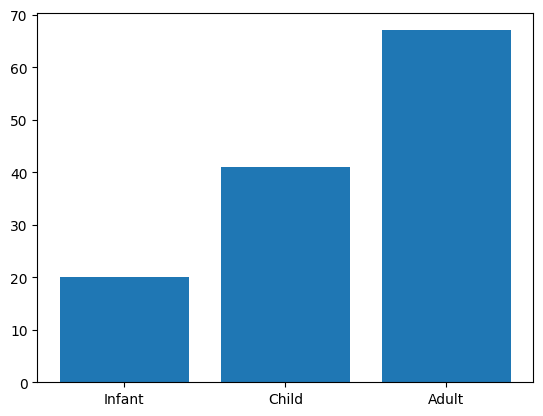

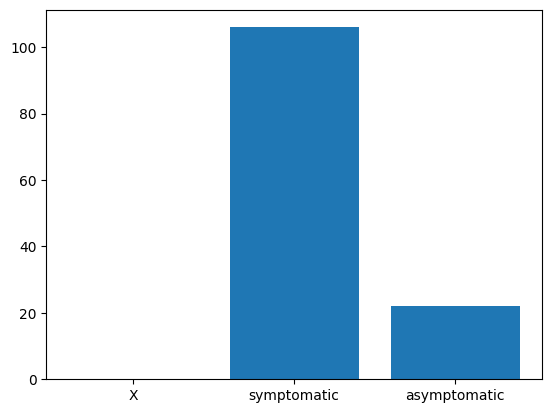

In [51]:
# check inclusion cases
# for each household get first infected individual and extract age, infection status
count_inclusion_cases_age = {0: 0, 1: 0, 2: 0}
count_symptomatic_cases = {0: 0, 1: 0, 2: 0}

for hh_id in sim_data['id_hh'].unique():
    hh_data = sim_data[sim_data['id_hh'] == hh_id]
    # check if there are multiple infection dates
    first_infected = hh_data.loc[hh_data['date_sympt'] == np.min(hh_data['date_sympt'])]
    min_age = int(np.min(first_infected['age']))
    min_status = int(np.min(first_infected['infect_status']))
    count_inclusion_cases_age[min_age] += 1
    count_symptomatic_cases[min_status] += 1
    #print(hh_data)
    
# plot cases
plt.bar(count_inclusion_cases_age.keys(), count_inclusion_cases_age.values())
plt.xticks([0, 1, 2], labels=['Infant', 'Child', 'Adult'])
plt.show()

plt.bar(count_symptomatic_cases.keys(), count_symptomatic_cases.values())
plt.xticks([0, 1, 2], labels=['X', 'symptomatic', 'asymptomatic'])
plt.show()

In [ ]:
sim_data_both = simulator_both_variants(np.concatenate((test, test)), selection_procedure='pedcov')

In [ ]:
sim_data_both

In [ ]:
normalize_household_data(sim_data, minimal_length=9)

In [ ]:
sim_data[sim_data['id_hh_origin'] == "42"]

In [ ]:
sim_data['id_hh_origin'].unique()

In [ ]:
# extract the original household ids
sim_data['id_hh_origin'].nunique()

In [ ]:
# columns: date_sympt_norm, infect_status_norm, age_norm, protected
# rows: empty individuals in the beginning (households are of same size)
# last row: end_followup_norm with 1

In [ ]:
# load a presimulation using pickle
import pickle
with open('presimulations/presim_file_1.pkl', 'rb') as f:
    presim = pickle.load(f)
    
with open('presimulations/presim_file_2.pkl', 'rb') as f:
    presim_2 = pickle.load(f)

In [ ]:
presim[0]['prior_draws']#-presim_2[5]['prior_draws']

In [ ]:
len(presim)

In [ ]:
presim_2[0]['prior_draws']#[:, :, :, 0]*1000

In [ ]:
with open('valid_data.pickle', 'rb') as f:
    valid_data = pickle.load(f)

In [ ]:
valid_data['prior_draws']